# 3. Model Development

Candidate selection, calibration and the checks that decide whether the model is usable. Everything here runs against the same code the API serves, imported from `src/loan_default`.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

DATA = "../data/Loan_Default.csv"

from sklearn.model_selection import train_test_split
from loan_default.config import get_settings
from loan_default.data.loader import load_dataset
from loan_default.models.registry import ModelRegistry

model, meta, metrics = ModelRegistry(get_settings().artifacts_dir).load('latest')
print('model version:', meta.model_version)
print('trained on   :', meta.n_training_rows, 'rows')
print('data sha256  :', meta.data_sha256[:16], '...')

model version: v20260821T011832Z
trained on   : 79709 rows
data sha256  : 4234b122f463ff4d ...


## What the model is allowed to see

The feature contract is configuration, not code, and every exclusion has a documented reason.

In [2]:
for reason, cols in meta.excluded_columns.items():
    print(f"{reason:14} {cols}")
print()
print(f"{len(meta.feature_columns)} features used")

leakage        ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges']
protected      ['Gender', 'age']
identifiers    ['ID', 'year']

26 features used


## Candidate selection

Chosen on cross-validated PR-AUC. At a 16% base rate, PR-AUC is a more informative summary than ROC-AUC, and accuracy is useless — predicting 'no default' for everyone scores 0.84.

In [3]:
pd.Series(metrics["candidate_cv_pr_auc"], name="CV PR-AUC").sort_values(ascending=False).round(4).to_frame()

,CV PR-AUC
xgboost,0.6191
random_forest,0.5596
logistic_regression,0.3897


The gap between logistic regression (0.39) and the tree ensembles is large, which is expected: the signal here is concentrated in categorical interactions that a linear model in the raw feature space cannot represent.

## Held-out performance

In [4]:
c = metrics["calibrated"]
summary = {
    "ROC-AUC": c["roc_auc"], "Gini": c["gini"], "PR-AUC": c["pr_auc"],
    "KS": c["ks_statistic"], "Brier": c["brier_score"],
    "mean predicted PD": c["mean_predicted_pd"],
    "observed default rate": c["base_rate"],
}
for k, v in summary.items():
    print(f"{k:24} {v:.4f}")
print()
print("95% CI on ROC-AUC:", [round(x, 4) for x in c["roc_auc_ci"]])

ROC-AUC                  0.8244
Gini                     0.6489
PR-AUC                   0.6104
KS                       0.4892
Brier                    0.0933
mean predicted PD        0.1654
observed default rate    0.1632

95% CI on ROC-AUC: [0.8166, 0.832]


## Calibration

A PD is not just a ranking here — it gets multiplied by LGD and EAD to produce a loss in currency. A model that ranks perfectly but says 5% when the truth is 15% understates expected loss threefold.

Both candidate calibrators were fitted on a held-out slice and measured:

In [5]:
comp = pd.DataFrame(metrics["calibration_comparison"]).T
comp[["brier_score", "calibration_error", "max_calibration_error", "roc_auc"]].round(5)

,brier_score,calibration_error,max_calibration_error,roc_auc
uncalibrated,0.093245,0.008838,0.030906,0.824923
isotonic,0.093332,0.005976,0.013552,0.824448
sigmoid,0.093823,0.023597,0.036124,0.824923


Isotonic roughly halves calibration error. Platt scaling makes it *worse than doing nothing* — its sigmoid assumption does not fit this score distribution.

Note also that Brier score barely moves. That is why selection is on calibration error: Brier mixes discrimination and calibration together and hides exactly the improvement being measured.

In [6]:
from loan_default.models.calibration import reliability_table
ds = load_dataset()
_, Xte, _, yte = train_test_split(ds.X, ds.y, test_size=.2, stratify=ds.y, random_state=42)
frame = Xte[meta.feature_columns]
p = model.predict_proba(frame)[:, 1]
tbl = reliability_table(yte, p)
tbl.round(4)

,n,predicted,observed,lower,upper,gap
0,3524,0.0317,0.0295,0.0143,0.0346,-0.0022
1,2461,0.0385,0.0398,0.0356,0.0407,0.0014
2,2314,0.0582,0.0501,0.0474,0.0596,-0.0081
3,2115,0.0653,0.0629,0.0642,0.0677,-0.0024
4,3804,0.0987,0.0852,0.0861,0.1078,-0.0136
5,1948,0.1109,0.1196,0.1079,0.1109,0.0087
6,2341,0.1357,0.1491,0.1111,0.1437,0.0134
7,1758,0.1830,0.1832,0.1629,0.1920,0.0002
8,2601,0.3107,0.3045,0.2303,0.4184,-0.0062
9,2044,0.7839,0.7803,0.4500,1.0000,-0.0036


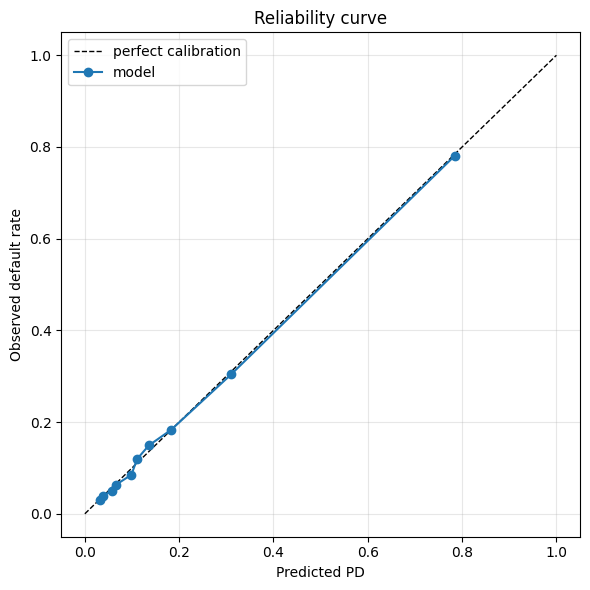

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.plot(tbl["predicted"], tbl["observed"], "o-", lw=1.5, label="model")
ax.set_xlabel("Predicted PD"); ax.set_ylabel("Observed default rate")
ax.set_title("Reliability curve"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()

## Risk grades

The check that decides whether these grades can support a lending decision: does the observed default rate increase monotonically from A to G?

In [8]:
from loan_default.risk.grades import grade_summary, is_monotonic
g = grade_summary(p, yte)
print("monotonic:", is_monotonic(g))
g[["grade","n","share","mean_pd","observed_default_rate"]].round(4)

monotonic: True


,grade,n,share,mean_pd,observed_default_rate
0,A,88,0.0035,0.0144,0.0000
1,B,5898,0.2368,0.0348,0.0342
2,C,5961,0.2393,0.0679,0.0589
3,D,8318,0.3339,0.1321,0.1354
4,E,1784,0.0716,0.2650,0.2618
5,F,1077,0.0432,0.4338,0.4234
6,G,1784,0.0716,0.8243,0.8206


Predicted and observed track closely at every grade, which is the calibration doing its job. Grade A holds only 88 loans with zero observed defaults — too thin to support a PD estimate, and noted as a limitation.

## Performance by segment

A single headline AUC can hide a segment where the model does not work. Lending decisions are made per applicant, so this matters.

In [9]:
from loan_default.models.segments import segment_report, format_report
print(format_report(segment_report(frame, yte, p)))

Overall ROC-AUC: 0.8244

--- Region ---
   segment     n  default_rate  mean_pd  calibration_gap  roc_auc
     North 12636        0.1447   0.1464          -0.0018   0.8244
     south 10604        0.1797   0.1822          -0.0025   0.8186
   central  1461        0.1951   0.1986          -0.0035   0.8357
North-East   209        0.2249   0.2289          -0.0040   0.8622

--- loan_purpose ---
segment     n  default_rate  mean_pd  calibration_gap  roc_auc
     p3 10273        0.1726   0.1781          -0.0055   0.8167
     p4  8072        0.1555   0.1558          -0.0003   0.8469
     p1  5972        0.1495   0.1499          -0.0004   0.8102
     p2   574        0.2509   0.2267           0.0242   0.7342

--- occupancy_type ---
segment     n  default_rate  mean_pd  calibration_gap  roc_auc
     pr 23010        0.1586   0.1621          -0.0035   0.8259
     ir  1362        0.2357   0.2203           0.0154   0.7984
     sr   538        0.1766   0.1683           0.0083   0.7885

--- credit_type 

Every segment clears the review thresholds. The weakest is `loan_purpose=p2` at 0.734 on 574 loans — worth watching, not worth blocking on.

## What drives a prediction

SHAP, aggregated back to the original features.

In [10]:
from loan_default.models.explain import PredictionExplainer
ex = PredictionExplainer(model)
imp = ex.global_importance(frame, sample=2000)
imp.head(12).round(4)

,feature,mean_abs_shap
0,LTV,0.4688
1,income,0.4254
2,dtir1,0.3459
3,submission_of_application,0.3024
4,loan_purpose,0.2675
5,loan_type,0.2540
6,Neg_ammortization,0.2097
7,loan_amount,0.2040
8,lump_sum_payment,0.1036
9,Region,0.1031


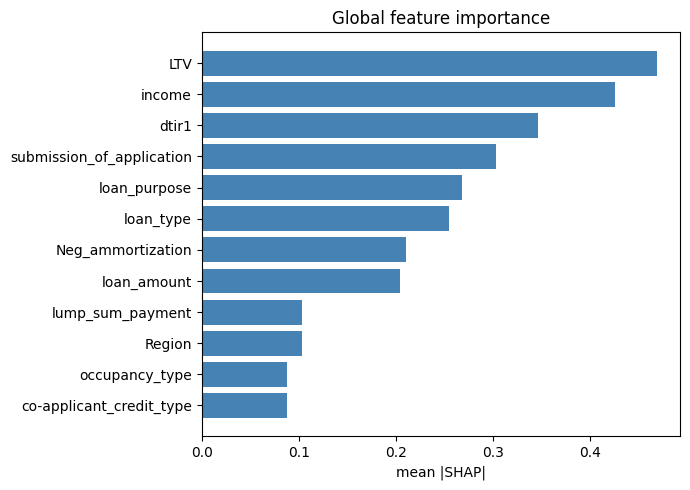

In [11]:
top = imp.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top["feature"], top["mean_abs_shap"], color="steelblue")
ax.set_xlabel("mean |SHAP|"); ax.set_title("Global feature importance")
plt.tight_layout()

Importance is spread across many features, which is what a real model looks like. Compare with the leaking version, where two features held 97.5% and 82 held nothing.

Note `Credit_Score` contributes very little — consistent with notebook 01, where it had a univariate AUC of 0.503.

## Limitations recorded with the model

In [12]:
for i, item in enumerate(meta.limitations, 1):
    print(f"{i}. {item}\n")

1. Credit_Score is not predictive in this dataset (univariate ROC-AUC 0.5030, flat default rate across all deciles) and appears to be randomly generated. Do not interpret its coefficient or SHAP value.

2. The dataset has no time dimension (year == 2019 for all rows), so no out-of-time validation, vintage analysis or macroeconomic conditioning is possible.

3. Trained on a single cross-section; behaviour under large input shocks is an extrapolation beyond the training distribution.

